In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/processed/cleaned_online_food_delivery.csv")

print("Dataset Loaded for EDA ✅")
print("Shape:", df.shape)
df.head()

Dataset Loaded for EDA ✅
Shape: (98986, 25)


,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,Unknown,Central,RES936,Restaurant_29,Chinese,2024-10-20,...,1197.0,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,39.0,Male,Delhi,Unknown,RES723,Restaurant_244,Arabian,2024-12-08,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,Unknown,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12


In [2]:
total_revenue = df['Final_Amount'].sum()

print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 156669446.0


In [3]:
aov = df['Final_Amount'].mean()

print("Average Order Value:", round(aov, 2))

Average Order Value: 1726.48


In [4]:
total_orders = df.shape[0]

print("Total Orders:", total_orders)

Total Orders: 98986


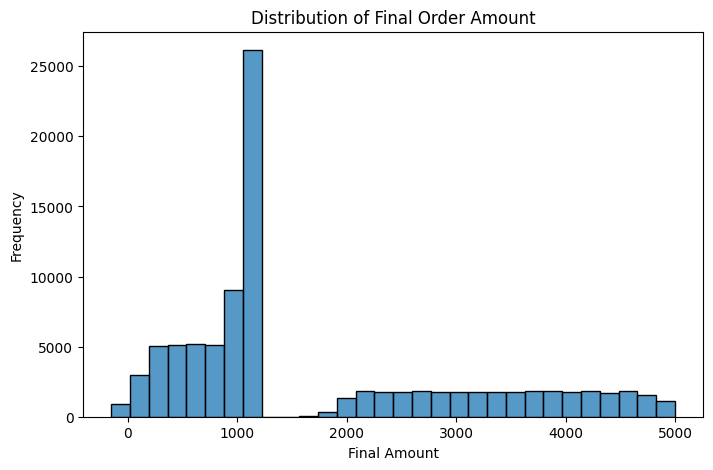

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['Final_Amount'], bins=30)
plt.title("Distribution of Final Order Amount")
plt.xlabel("Final Amount")
plt.ylabel("Frequency")
plt.show()

In [6]:
revenue_by_city = df.groupby('City')['Final_Amount'].sum().sort_values(ascending=False)

revenue_by_city

City
Bangalore    26491332.0
Hyderabad    26295287.0
Unknown      26197622.0
Delhi        25950053.0
Chennai      25887680.0
Mumbai       25847472.0
Name: Final_Amount, dtype: float64

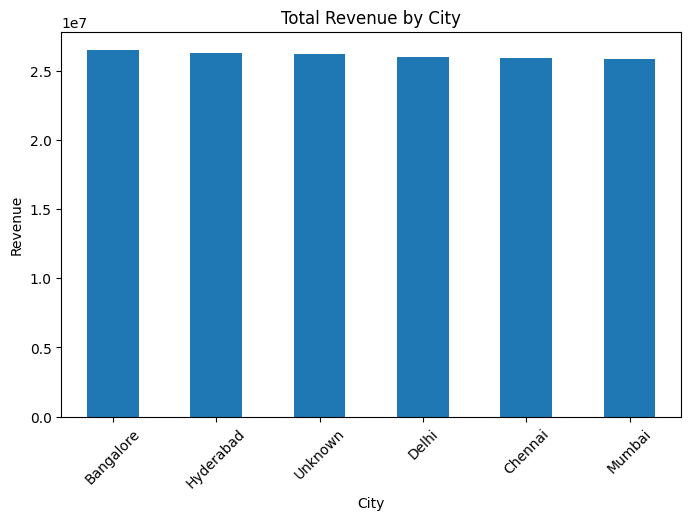

In [7]:
plt.figure(figsize=(8,5))
revenue_by_city.plot(kind='bar')
plt.title("Total Revenue by City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [8]:
orders_by_city = df.groupby('City')['Order_ID'].count().sort_values(ascending=False)

orders_by_city

City
Hyderabad    16713
Bangalore    16567
Unknown      16552
Delhi        16521
Mumbai       16321
Chennai      16312
Name: Order_ID, dtype: int64

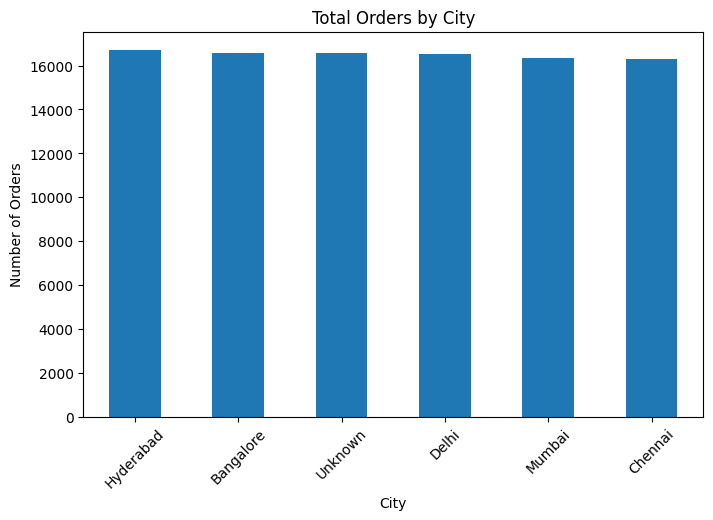

In [9]:
plt.figure(figsize=(8,5))
orders_by_city.plot(kind='bar')
plt.title("Total Orders by City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [10]:
aov_by_city = df.groupby('City')['Final_Amount'].mean().sort_values(ascending=False)

aov_by_city

City
Bangalore    1740.903726
Chennai      1732.312634
Unknown      1727.277774
Mumbai       1725.811044
Hyderabad    1718.084744
Delhi        1714.572382
Name: Final_Amount, dtype: float64

In [11]:

aov_by_city.plot(kind='bar')
plt.title("Average Order Value by City")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.show()plt.figure(figsize=(8,5))

SyntaxError: invalid syntax (2229679264.py, line 5)

In [ ]:
revenue_by_cuisine = df.groupby('Cuisine_Type')['Final_Amount'].sum().sort_values(ascending=False)

revenue_by_cuisine

Cuisine_Type
Unknown    26548563.0
Indian     26373982.0
Chinese    26209255.0
Mexican    26088230.0
Arabian    25798221.0
Italian    25651195.0
Name: Final_Amount, dtype: float64

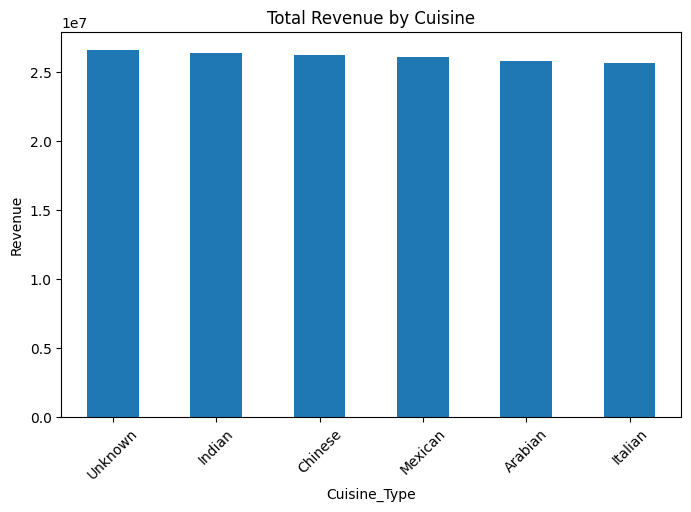

In [ ]:
plt.figure(figsize=(8,5))
revenue_by_cuisine.plot(kind='bar')
plt.title("Total Revenue by Cuisine")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
orders_by_cuisine = df.groupby('Cuisine_Type')['Order_ID'].count().sort_values(ascending=False)

orders_by_cuisine

Cuisine_Type
Unknown    16689
Indian     16535
Chinese    16486
Arabian    16475
Mexican    16419
Italian    16382
Name: Order_ID, dtype: int64

In [ ]:
aov_by_cuisine = df.groupby('Cuisine_Type')['Final_Amount'].mean().sort_values(ascending=False)

aov_by_cuisine

Cuisine_Type
Chinese    1736.057164
Unknown    1735.653962
Indian     1734.673902
Mexican    1732.976618
Italian    1713.277785
Arabian    1706.005885
Name: Final_Amount, dtype: float64

In [ ]:
avg_delivery_time = df['Delivery_Time_Min'].mean()

print("Average Delivery Time (minutes):", round(avg_delivery_time, 2))

Average Delivery Time (minutes): 125.26


In [ ]:
delivery_time_by_city = df.groupby('City')['Delivery_Time_Min'].mean().sort_values(ascending=False)

delivery_time_by_city

City
Mumbai       126.360996
Hyderabad    125.321616
Unknown      125.310892
Delhi        125.167464
Chennai      124.827931
Bangalore    124.570376
Name: Delivery_Time_Min, dtype: float64

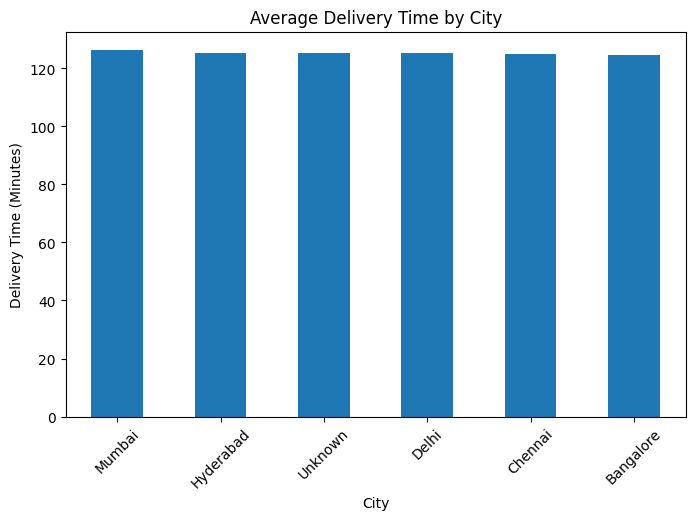

In [ ]:
plt.figure(figsize=(8,5))
delivery_time_by_city.plot(kind='bar')
plt.title("Average Delivery Time by City")
plt.ylabel("Delivery Time (Minutes)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.groupby('Delivery_Rating')['Delivery_Time_Min'].mean()

Delivery_Rating
1.0          125.256544
2.0          125.155507
3.0          124.702028
4.0          125.989726
5.0          125.766537
No Rating    124.663816
Name: Delivery_Time_Min, dtype: float64

In [ ]:
cancellation_by_city = df[df['Order_Status'] == 'Cancelled'].groupby('City')['Order_ID'].count()

total_orders_by_city = df.groupby('City')['Order_ID'].count()

cancellation_rate_city = (cancellation_by_city / total_orders_by_city) * 100

cancellation_rate_city.sort_values(ascending=False)

City
Hyderabad    15.161850
Delhi        15.083833
Chennai      15.068661
Unknown      15.049541
Mumbai       14.950064
Bangalore    14.915193
Name: Order_ID, dtype: float64

In [ ]:
df[df['Order_Status'] == 'Cancelled']['Cancellation_Reason'].value_counts()

Cancellation_Reason
Late Delivery         3032
Customer Cancelled    2963
Restaurant Issue      2949
Name: count, dtype: int64

In [ ]:
df.groupby('Order_Status')['Delivery_Time_Min'].mean()

Order_Status
Cancelled    127.652455
Delivered    124.976552
Name: Delivery_Time_Min, dtype: float64

In [ ]:
df['Profit_Margin'].describe()

count    98986.000000
mean         0.150394
std          0.201872
min         -0.200000
25%         -0.020000
50%          0.150000
75%          0.320000
max          0.500000
Name: Profit_Margin, dtype: float64

In [ ]:
df.groupby('City')['Profit_Margin'].mean().sort_values(ascending=False)

City
Mumbai       0.152455
Unknown      0.152334
Delhi        0.150404
Bangalore    0.150312
Hyderabad    0.148492
Chennai      0.148383
Name: Profit_Margin, dtype: float64

In [ ]:
#Feature engineering
# Create Age Group
bins = [18, 25, 35, 45, 60]
labels = ['18-25', '26-35', '36-45', '46-60']

df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=True)

df['Age_Group'].value_counts()

Age_Group
36-45    61065
46-60    17229
26-35    11552
18-25     7995
Name: count, dtype: int64

In [ ]:
#categorizes profit margins
def profit_category(x):
    if x < 0:
        return "Loss"
    elif x < 0.15:
        return "Low Profit"
    elif x < 0.30:
        return "Medium Profit"
    else:
        return "High Profit"

df['Profit_Category'] = df['Profit_Margin'].apply(profit_category)

df['Profit_Category'].value_counts()

Profit_Category
High Profit      29039
Loss             27445
Medium Profit    21310
Low Profit       21192
Name: count, dtype: int64

In [ ]:
#categorizes delivery speed
def delivery_speed(x):
    if x <= 60:
        return "Fast"
    elif x <= 120:
        return "Moderate"
    else:
        return "Slow"

df['Delivery_Speed_Category'] = df['Delivery_Time_Min'].apply(delivery_speed)

df['Delivery_Speed_Category'].value_counts()

Delivery_Speed_Category
Slow        37902
Moderate    34753
Fast        26331
Name: count, dtype: int64

In [ ]:
#categorizes revenue category
def revenue_category(x):
    if x < 1000:
        return "Low Value"
    elif x < 3000:
        return "Medium Value"
    else:
        return "High Value"

df['Revenue_Category'] = df['Final_Amount'].apply(revenue_category)

df['Revenue_Category'].value_counts()

Revenue_Category
Medium Value    38763
Low Value       32043
High Value      28180
Name: count, dtype: int64

In [ ]:
df['Cancellation_Flag'] = df['Order_Status'].apply(lambda x: 1 if x == 'Cancelled' else 0)

df['Cancellation_Flag'].value_counts()

Cancellation_Flag
0    84100
1    14886
Name: count, dtype: int64

In [ ]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Age_Group,Profit_Category,Delivery_Speed_Category,Revenue_Category,Cancellation_Flag
0,ORD000001,CUST6948,19.0,Male,Unknown,Central,RES936,Restaurant_29,Chinese,2024-10-20,...,5.0,4.4,Weekend,True,0.13,18-25,Low Profit,Slow,Medium Value,0
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,...,5.0,4.7,Weekday,True,0.48,36-45,High Profit,Fast,High Value,0
2,ORD000003,CUST1765,39.0,Male,Delhi,Unknown,RES723,Restaurant_244,Arabian,2024-12-08,...,4.0,4.9,Weekend,True,0.08,36-45,Low Profit,Slow,Low Value,0
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,...,2.0,3.4,Weekday,Unknown,0.04,36-45,Low Profit,Slow,High Value,1
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,...,2.0,4.4,Weekend,False,0.12,46-60,Low Profit,Fast,Low Value,0


In [ ]:
df.to_csv("../data/processed/cleaned_online_food_delivery.csv", index=False)

print("Updated dataset with engineered features saved ✅")

Updated dataset with engineered features saved ✅


In [ ]:
# Dataset basic check
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset Shape: (98986, 30)

Columns:
Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km',
       'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode',
       'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID',
       'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour',
       'Profit_Margin', 'Age_Group', 'Profit_Category',
       'Delivery_Speed_Category', 'Revenue_Category', 'Cancellation_Flag'],
      dtype='object')


In [ ]:
# Data types
print("\nData Types:")
print(df.dtypes)

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())


Data Types:
Order_ID                     object
Customer_ID                  object
Customer_Age                float64
Customer_Gender              object
City                         object
Area                         object
Restaurant_ID                object
Restaurant_Name              object
Cuisine_Type                 object
Order_Date                   object
Order_Time                   object
Delivery_Time_Min           float64
Distance_km                 float64
Order_Value                 float64
Discount_Applied            float64
Final_Amount                float64
Payment_Mode                 object
Order_Status                 object
Cancellation_Reason          object
Delivery_Partner_ID          object
Delivery_Rating              object
Restaurant_Rating           float64
Order_Day                    object
Peak_Hour                    object
Profit_Margin               float64
Age_Group                  category
Profit_Category              object
Delivery_Speed_

In [ ]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
# Outlier detection for Order_Value using IQR

Q1 = df['Order_Value'].quantile(0.25)
Q3 = df['Order_Value'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Outlier rows
outliers = df[(df['Order_Value'] < lower_bound) | (df['Order_Value'] > upper_bound)]

print("Number of Outliers:", outliers.shape)

Lower Bound: -1777.0
Upper Bound: 5455.0
Number of Outliers: (0, 30)


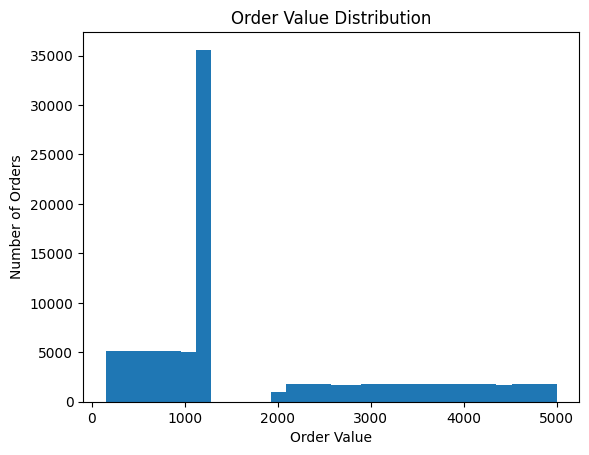

In [ ]:
import matplotlib.pyplot as plt

# Order value distribution
plt.hist(df['Order_Value'], bins=30)

plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")

plt.show()

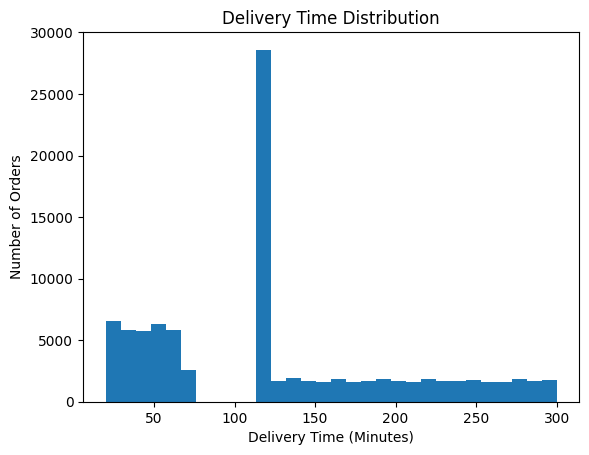

In [ ]:
plt.hist(df['Delivery_Time_Min'], bins=30)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")

plt.show()

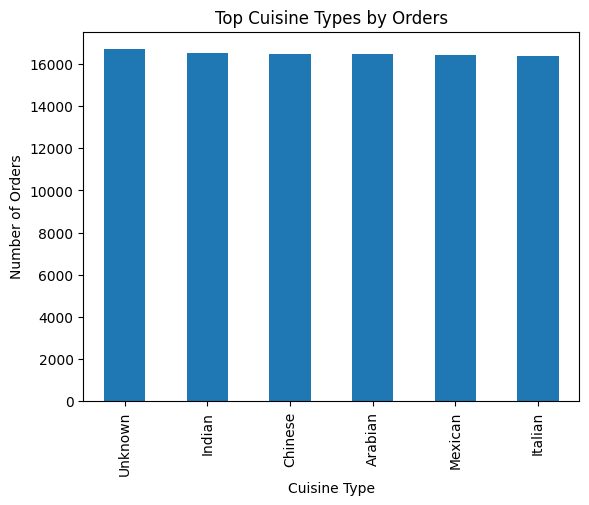

In [ ]:
cuisine_orders = df['Cuisine_Type'].value_counts().head(10)

cuisine_orders.plot(kind='bar')

plt.title("Top Cuisine Types by Orders")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")

plt.show()

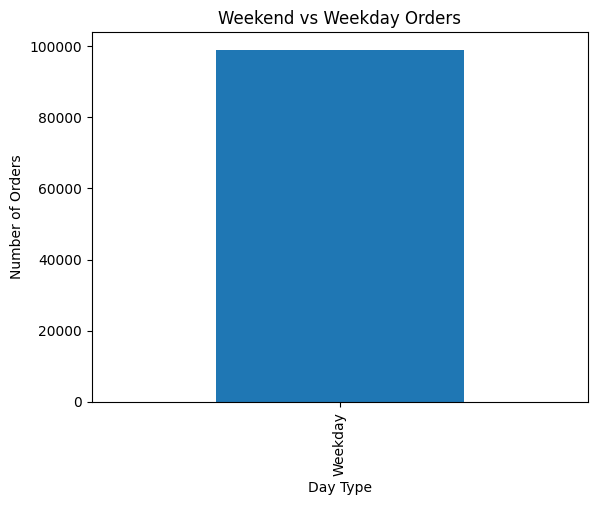

In [ ]:
df['Day_Type'] = df['Order_Day'].apply(lambda x: 'Weekend' if x in ['Saturday','Sunday'] else 'Weekday')

day_orders = df['Day_Type'].value_counts()

day_orders.plot(kind='bar')

plt.title("Weekend vs Weekday Orders")
plt.xlabel("Day Type")
plt.ylabel("Number of Orders")

plt.show()

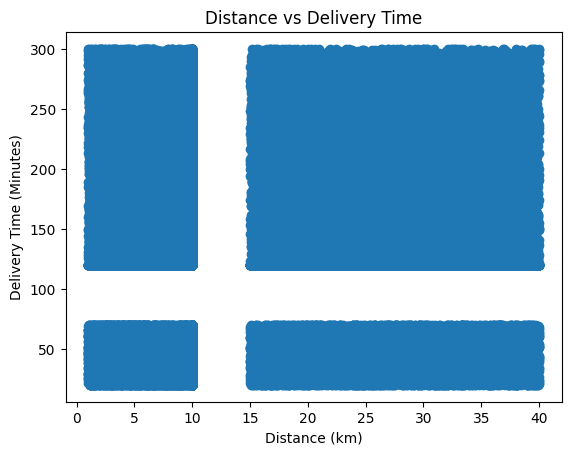

In [ ]:
plt.scatter(df['Distance_km'], df['Delivery_Time_Min'])

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Minutes)")

plt.show()

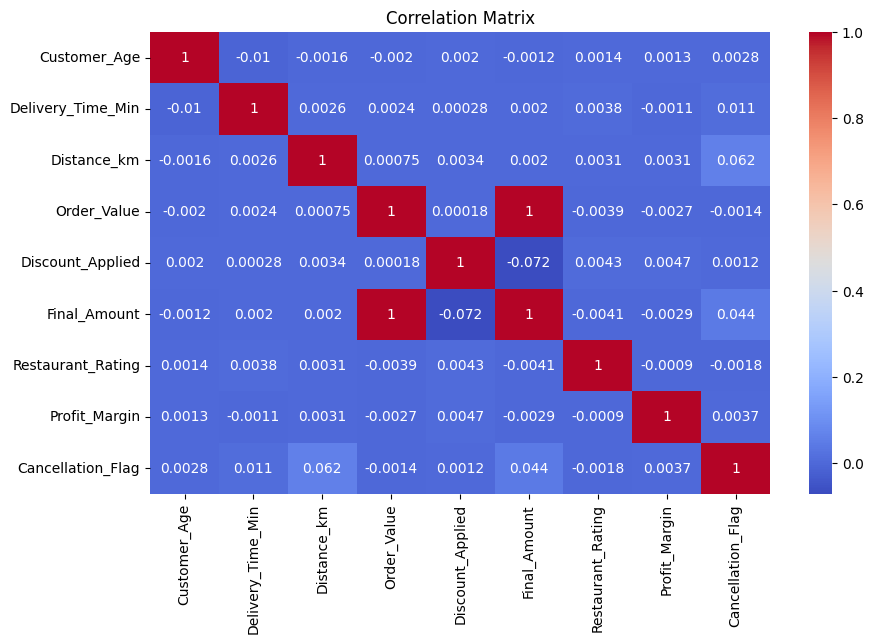

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['float64','int64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

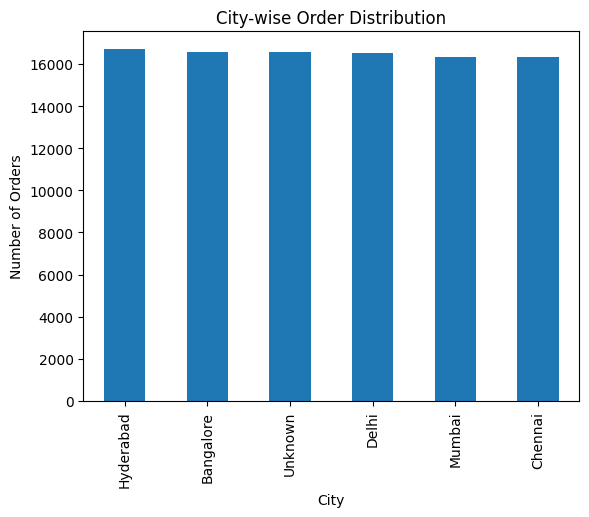

In [ ]:
city_orders = df['City'].value_counts()

city_orders.plot(kind='bar')

plt.title("City-wise Order Distribution")
plt.xlabel("City")
plt.ylabel("Number of Orders")

plt.show()

In [ ]:
df[['Order_Day','Peak_Hour','Age_Group','Profit_Category','Delivery_Speed_Category','Revenue_Category']].head()

,Order_Day,Peak_Hour,Age_Group,Profit_Category,Delivery_Speed_Category,Revenue_Category
0,Weekend,True,18-25,Low Profit,Slow,Medium Value
1,Weekday,True,36-45,High Profit,Fast,High Value
2,Weekend,True,36-45,Low Profit,Slow,Low Value
3,Weekday,Unknown,36-45,Low Profit,Slow,High Value
4,Weekend,False,46-60,Low Profit,Fast,Low Value


In [ ]:
top_customers = df.groupby('Customer_ID')['Final_Amount'].sum().sort_values(ascending=False).head(10)

print(top_customers)

Customer_ID
CUST5267    48727.0
CUST6706    47539.0
CUST1606    47488.0
CUST6252    45128.0
CUST1239    44336.0
CUST5534    44271.0
CUST6457    43913.0
CUST4431    43238.0
CUST1258    43212.0
CUST9017    41610.0
Name: Final_Amount, dtype: float64


In [ ]:
age_order_value = df.groupby('Age_Group')['Final_Amount'].mean()

print(age_order_value)

Age_Group
18-25    1714.666848
26-35    1747.002256
36-45    1723.218617
46-60    1728.927186
Name: Final_Amount, dtype: float64


C:\Users\keert\AppData\Local\Temp\ipykernel_16608\4072313256.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_order_value = df.groupby('Age_Group')['Final_Amount'].mean()


In [ ]:
day_pattern = df.groupby('Order_Day')['Order_ID'].count()

print(day_pattern)

Order_Day
Weekday    70618
Weekend    28368
Name: Order_ID, dtype: int64


In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

monthly_revenue = df.groupby(df['Order_Date'].dt.month)['Final_Amount'].sum()

print(monthly_revenue)

Order_Date
1     13432924.0
2     12465598.0
3     13134870.0
4     12809775.0
5     13311384.0
6     13011375.0
7     13652789.0
8     13101063.0
9     13100132.0
10    12957367.0
11    12913186.0
12    12778983.0
Name: Final_Amount, dtype: float64


In [ ]:
discount_profit = df.groupby('Discount_Applied')['Profit_Margin'].mean()

print(discount_profit)

Discount_Applied
0.0      0.150140
20.0     0.149622
50.0     0.148516
100.0    0.151579
300.0    0.152360
Name: Profit_Margin, dtype: float64


In [ ]:
city_revenue = df.groupby('City')['Final_Amount'].sum().sort_values(ascending=False)

print(city_revenue)

City
Bangalore    26491332.0
Hyderabad    26295287.0
Unknown      26197622.0
Delhi        25950053.0
Chennai      25887680.0
Mumbai       25847472.0
Name: Final_Amount, dtype: float64


In [ ]:
delivery_city = df.groupby('City')['Delivery_Time_Min'].mean()

print(delivery_city)

City
Bangalore    124.570376
Chennai      124.827931
Delhi        125.167464
Hyderabad    125.321616
Mumbai       126.360996
Unknown      125.310892
Name: Delivery_Time_Min, dtype: float64


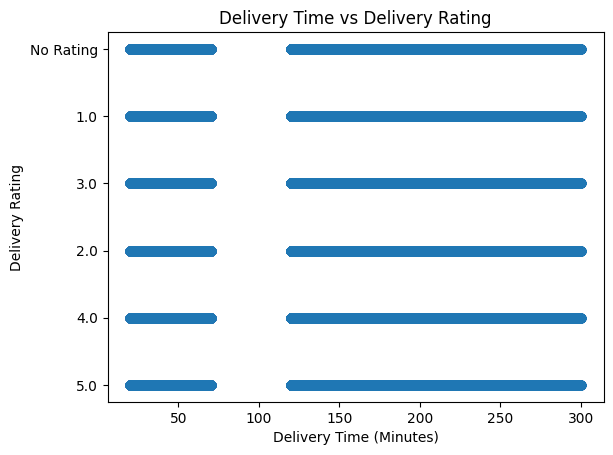

In [ ]:
plt.scatter(df['Delivery_Time_Min'], df['Delivery_Rating'])

plt.title("Delivery Time vs Delivery Rating")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Delivery Rating")

plt.show()

In [ ]:
top_restaurants = df.groupby('Restaurant_Name')['Restaurant_Rating'].mean().sort_values(ascending=False).head(10)

print(top_restaurants)

Restaurant_Name
Restaurant_162    4.388889
Restaurant_101    4.388701
Restaurant_496    4.383582
Restaurant_355    4.369274
Restaurant_1      4.367708
Restaurant_352    4.365104
Restaurant_481    4.364021
Restaurant_119    4.357471
Restaurant_392    4.356354
Restaurant_209    4.355502
Name: Restaurant_Rating, dtype: float64


In [ ]:
cancel_rate = df.groupby('Restaurant_Name')['Cancellation_Flag'].mean().sort_values(ascending=False).head(10)

print(cancel_rate)

Restaurant_Name
Restaurant_202    0.220000
Restaurant_477    0.218391
Restaurant_391    0.216495
Restaurant_390    0.216080
Restaurant_299    0.213542
Restaurant_113    0.211823
Restaurant_455    0.211111
Restaurant_373    0.210526
Restaurant_437    0.209756
Restaurant_361    0.209040
Name: Cancellation_Flag, dtype: float64


In [ ]:
peak_orders = df['Peak_Hour'].value_counts()

print(peak_orders)

Peak_Hour
False      33225
True       33141
Unknown    32620
Name: count, dtype: int64


In [ ]:
payment_pref = df['Payment_Mode'].value_counts()

print(payment_pref)

Payment_Mode
Card       19888
Wallet     19885
COD        19767
UPI        19731
Unknown    19715
Name: count, dtype: int64


In [ ]:
cancel_reason = df['Cancellation_Reason'].value_counts()

print(cancel_reason)

Cancellation_Reason
Late Delivery         3032
Customer Cancelled    2963
Restaurant Issue      2949
Name: count, dtype: int64
